## Capstone Project of RML (Group 4) - HMDA dataset 

### Pre-modeling 

#### 1.	Data inspection

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

#### Load data with DuckDB → Parquet

The raw `2024_lar.txt` file is ~12M rows and 100+ columns — loading it with `pd.read_csv` every time is slow and memory-hungry. Instead we:

1. Use **DuckDB** to stream the file and keep only the columns our analysis uses.
2. Cast numeric columns to real numbers inside the SQL query so sentinel values like `"NA"` and `"Exempt"` become `NULL` immediately (no more `object`-dtype numeric columns).
3. Write the result as a compressed **Parquet** file. Re-runs skip straight to the Parquet and load in seconds.

In [2]:
# Run once. Safe to re-run.
%pip install -q duckdb pyarrow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import duckdb
import pandas as pd

raw_txt_path = "2024_lar.txt"                  # original pipe-delimited file
parquet_path = "2024_lar_subset.parquet"       # trimmed + typed output

# Columns that should be real numbers.
# TRY_CAST turns anything unparseable (e.g. "NA", "Exempt", blanks) into NULL.
numeric_cols = [
    "income",
    "loan_amount",
    "loan_term",
    "combined_loan_to_value_ratio",
    "property_value",
    "tract_minority_population_percent",
    "action_taken",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type",
]

# Columns that should stay as strings (categorical / codes / ranges).
string_cols = [
    "derived_race",
    "derived_ethnicity",
    "derived_sex",
    "debt_to_income_ratio",   # values like "20%-<30%"
    "state_code",             # two-letter codes like "CA"
]

# Build the SELECT list: cast numerics to DOUBLE, keep strings as VARCHAR.
select_parts = (
    [f"TRY_CAST({c} AS DOUBLE) AS {c}" for c in numeric_cols]
    + [f"CAST({c} AS VARCHAR) AS {c}" for c in string_cols]
)
select_sql = ",\n            ".join(select_parts)

con = duckdb.connect()  # in-memory

# Build the Parquet file if we don't have it yet.
# (Delete the .parquet file if you change the column list and want to rebuild.)
if not os.path.exists(parquet_path):
    print(f"Reading {raw_txt_path} with DuckDB and writing {parquet_path} ...")
    con.execute(f"""
        COPY (
            SELECT
                {select_sql}
            FROM read_csv_auto(
                '{raw_txt_path}',
                delim='|',
                header=True,
                all_varchar=True,         -- read everything as text first
                nullstr=['NA', 'Exempt']  -- treat these as NULL up front
            )
        )
        TO '{parquet_path}' (FORMAT PARQUET, COMPRESSION ZSTD);
    """)
    print("Done.")
else:
    print(f"{parquet_path} already exists, skipping conversion.")

# Load the Parquet into pandas. This replaces the old pd.read_csv(...) call.
raw_data = con.execute(f"SELECT * FROM '{parquet_path}'").df()

# Sanity checks
print(f"\nRows: {len(raw_data):,}")
print(f"Columns: {list(raw_data.columns)}")
print("\ndtypes:")
print(raw_data.dtypes)

# Keep same return-value behavior as the original cell
raw_data.shape[0]


Reading 2024_lar.txt with DuckDB and writing 2024_lar_subset.parquet ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Rows: 12,259,129
Columns: ['income', 'loan_amount', 'loan_term', 'combined_loan_to_value_ratio', 'property_value', 'tract_minority_population_percent', 'action_taken', 'loan_type', 'loan_purpose', 'applicant_credit_score_type', 'derived_race', 'derived_ethnicity', 'derived_sex', 'debt_to_income_ratio', 'state_code']

dtypes:
income                               float64
loan_amount                          float64
loan_term                            float64
combined_loan_to_value_ratio         float64
property_value                       float64
tract_minority_population_percent    float64
action_taken                         float64
loan_type                            float64
loan_purpose                         float64
applicant_credit_score_type          float64
derived_race                          object
derived_ethnicity                     object
derived_sex                           object
debt_to_income_ratio                  object
state_code                            obje

12259129

In [7]:
# Convert any pandas StringDtype columns to plain object dtype with np.nan.
# sklearn's SimpleImputer can't handle pd.NA, only np.nan.
import numpy as np

for col in raw_data.select_dtypes(include=["string"]).columns:
    raw_data[col] = raw_data[col].astype(object)
    raw_data.loc[raw_data[col].isna(), col] = np.nan

In [4]:
raw_data.head(10)

,income,loan_amount,loan_term,combined_loan_to_value_ratio,property_value,tract_minority_population_percent,action_taken,loan_type,loan_purpose,applicant_credit_score_type,derived_race,derived_ethnicity,derived_sex,debt_to_income_ratio,state_code
0,167.0,55000.0,60.0,50.432,565000.0,11.78,1.0,1.0,2.0,11.0,White,Not Hispanic or Latino,Joint,20%-<30%,UT
1,109.0,55000.0,120.0,79.805,365000.0,14.72,3.0,1.0,4.0,11.0,White,Not Hispanic or Latino,Male,>60%,UT
2,97.0,215000.0,60.0,76.465,485000.0,11.73,1.0,1.0,31.0,11.0,White,Not Hispanic or Latino,Joint,49,UT
3,87.0,105000.0,60.0,51.365,665000.0,18.52,1.0,1.0,2.0,11.0,White,Not Hispanic or Latino,Male,45,UT
4,193.0,75000.0,120.0,79.050,835000.0,42.30,1.0,1.0,2.0,9.0,White,Not Hispanic or Latino,Joint,44,NV
5,271.0,155000.0,60.0,39.403,535000.0,51.92,1.0,1.0,31.0,11.0,White,Hispanic or Latino,Female,40,UT
6,72.0,75000.0,60.0,85.654,355000.0,16.67,1.0,1.0,2.0,11.0,White,Not Hispanic or Latino,Joint,47,UT
7,83.0,25000.0,60.0,61.025,445000.0,20.32,1.0,1.0,31.0,11.0,White,Not Hispanic or Latino,Joint,20%-<30%,UT
8,194.0,155000.0,60.0,80.125,555000.0,24.97,1.0,1.0,4.0,9.0,White,Not Hispanic or Latino,Joint,50%-60%,UT
9,143.0,75000.0,120.0,80.240,435000.0,19.36,1.0,1.0,2.0,11.0,White,Not Hispanic or Latino,Male,20%-<30%,UT


In [5]:
list(raw_data.columns)

['income',
 'loan_amount',
 'loan_term',
 'combined_loan_to_value_ratio',
 'property_value',
 'tract_minority_population_percent',
 'action_taken',
 'loan_type',
 'loan_purpose',
 'applicant_credit_score_type',
 'derived_race',
 'derived_ethnicity',
 'derived_sex',
 'debt_to_income_ratio',
 'state_code']

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12259129 entries, 0 to 12259128
Data columns (total 15 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   income                             float64
 1   loan_amount                        float64
 2   loan_term                          float64
 3   combined_loan_to_value_ratio       float64
 4   property_value                     float64
 5   tract_minority_population_percent  float64
 6   action_taken                       float64
 7   loan_type                          float64
 8   loan_purpose                       float64
 9   applicant_credit_score_type        float64
 10  derived_race                       object 
 11  derived_ethnicity                  object 
 12  derived_sex                        object 
 13  debt_to_income_ratio               object 
 14  state_code                         object 
dtypes: float64(10), object(5)
memory usage: 1.4+ GB


#### 2.	Target construction

We construct a binary target variable based on the `action_taken` field, where approved applications (values 1 and 2) are labeled as 1, and denied applications (value 3) are labeled as 0. All other categories are excluded to ensure a clean binary classification setup.

In [7]:
import numpy as np

# Create a copy of the original dataset to avoid modifying raw data
df = raw_data.copy()

# Step 1: Filter the dataset to keep only relevant action_taken values
# Keep:
# 1 = Loan originated
# 2 = Approved but not accepted
# 3 = Denied
# Remove all other categories (e.g., withdrawn, incomplete, etc.)
df = df[df["action_taken"].isin([1, 2, 3])]

# Step 2: Create a binary target variable
# Approved (1, 2) → 1
# Denied (3) → 0
df["target"] = np.where(
    df["action_taken"].isin([1, 2]),  # approved cases
    1,
    0  # denied cases
)

# Step 3: Check the distribution of the target variable
# This helps us understand class balance (approved vs denied)
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
1    6558317
0    2103460
Name: count, dtype: int64
target
1    0.757156
0    0.242844
Name: proportion, dtype: float64



The constructed target variable shows that approximately 75.7% of applications are approved, while 24.3% are denied. This class imbalance reflects real-world lending patterns, where approvals are more frequent than denials. This imbalance has important implications for both model performance and fairness evaluation. In particular, a model may achieve high accuracy by favoring the majority class, while still performing poorly on denied cases. As a result, it is critical to examine error rates such as false positive rate (FPR) and false negative rate (FNR), especially across different demographic groups, in subsequent analysis.

#### 3. Data cleaning

**Converting values into `NaN`** 

In this dataset, values such as "NA" and "Exempt" represent missing or non-applicable information, but they are stored as text rather than true missing values. Since Python does not automatically recognize these strings as missing, they may be mistakenly treated as valid data or distinct categories. This can distort both statistical analysis and model training.

Therefore, we convert these values into `NaN`, which allows the system to correctly identify them as missing. This step is important for ensuring accurate calculation of missingness and for maintaining data quality in later stages of the analysis.

In [8]:
df = df.replace(["NA", "Exempt"], np.nan)

**Identifying Missing Values**

After converting "NA" and "Exempt" into `NaN`, we calculate the proportion of missing values for each column. This allows us to clearly see how much data is missing in each feature. By sorting the results, we can easily identify columns with very high missing rates, which may need to be removed or handled carefully in later steps.

In [9]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

debt_to_income_ratio                 0.108749
combined_loan_to_value_ratio         0.104863
property_value                       0.065782
income                               0.062982
loan_term                            0.047586
state_code                           0.005253
loan_amount                          0.000000
tract_minority_population_percent    0.000000
loan_type                            0.000000
action_taken                         0.000000
loan_purpose                         0.000000
applicant_credit_score_type          0.000000
derived_ethnicity                    0.000000
derived_race                         0.000000
derived_sex                          0.000000
target                               0.000000
dtype: float64

**Dropping Columns with More Than 90% Missing Values**

To ensure data quality, we remove columns with excessive missingness. Specifically, we identify all columns where more than 90% of the values are missing and drop them from the dataset.

This step helps eliminate features that provide little useful information and could negatively impact model performance or analysis results. By retaining only columns with sufficient data, we create a more robust and reliable dataset for further processing.

In [10]:
cols_to_drop = missing[missing > 0.9].index
df = df.drop(columns=cols_to_drop)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8661777 entries, 0 to 12259128
Data columns (total 16 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   income                             float64
 1   loan_amount                        float64
 2   loan_term                          float64
 3   combined_loan_to_value_ratio       float64
 4   property_value                     float64
 5   tract_minority_population_percent  float64
 6   action_taken                       float64
 7   loan_type                          float64
 8   loan_purpose                       float64
 9   applicant_credit_score_type        float64
 10  derived_race                       object 
 11  derived_ethnicity                  object 
 12  derived_sex                        object 
 13  debt_to_income_ratio               object 
 14  state_code                         object 
 15  target                             int64  
dtypes: float64(10), int64(

**Data Type Conversion**

In this step, we adjust the data types of selected variables to better reflect their actual meaning.

For variables such as `income` and `loan_amount`, although they look like numbers, they are stored as strings due to the presence of values like "NA" or "Exempt". If we do not convert them, numerical operations may fail or produce incorrect results. Therefore, we convert these columns into numeric types, allowing proper calculations in later analysis.

For variables such as `derived_race`, `derived_ethnicity`, and `derived_sex`, they are clearly categorical in nature. Even though they are stored as object types, this does not explicitly indicate that they are categories. By converting them to `category`, we ensure they are properly recognized as grouped variables, which is important for fairness analysis and for encoding in the modeling stage.

This step helps ensure that the dataset is correctly structured for further analysis and modeling.

In [12]:
# Numeric columns are already float64 coming out of Parquet (DuckDB cast them),
# so pd.to_numeric here is a no-op safeguard.
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

# Convert demographic categoricals
cat_cols = ["derived_race", "derived_ethnicity", "derived_sex"]
for col in cat_cols:
    df[col] = df[col].astype("category")


#### 4.	Baseline fairness analysis (pre-model)

Before building the model, we first examine fairness in the raw data by comparing approval rates across different demographic groups, including race, ethnicity, and sex.

These variables represent key protected attributes, and analyzing them helps us understand whether there are existing disparities in lending outcomes. If certain groups have consistently lower approval rates, this may indicate potential bias or structural differences in the data.

This step is important because it allows us to separate data-driven disparities from model-driven bias. By establishing a baseline, we can later evaluate whether the model reduces, preserves, or amplifies these differences.

Therefore, pre-model fairness analysis is a critical step in responsible machine learning, as it provides essential context for interpreting model results.

In [13]:
df.groupby("derived_race")["target"].mean().sort_values()

derived_race
Free Form Text Only                          0.410526
Native Hawaiian or Other Pacific Islander    0.613013
2 or more minority races                     0.619721
American Indian or Alaska Native             0.629659
Black or African American                    0.633432
Race Not Available                           0.722384
White                                        0.781921
Asian                                        0.787293
Joint                                        0.804574
Name: target, dtype: float64

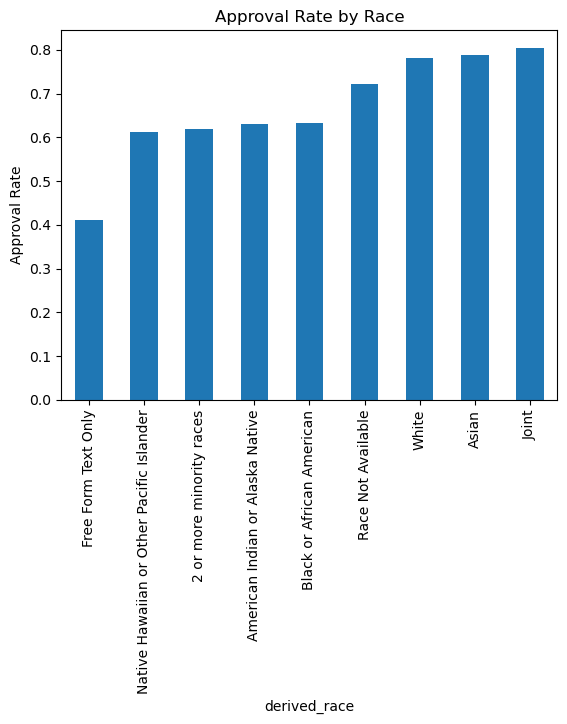

In [14]:
import matplotlib.pyplot as plt

df.groupby("derived_race")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race")
plt.show()

**Approval Rate by Race**

The approval rate varies significantly across racial groups, indicating the presence of disparities in the raw data. In particular, applicants identified as White and Asian exhibit higher approval rates compared to other groups such as Black or African American. Additionally, the "Joint" category, which represents applications involving multiple applicants, shows one of the highest approval rates. This may reflect stronger combined financial profiles rather than group-specific effects. On the other hand, the "Free Form Text Only" category has a notably lower approval rate. Since this category represents non-standard or self-reported entries, it may reflect data quality issues or incomplete demographic information. Overall, these results suggest that disparities exist across racial groups even before modeling, highlighting the importance of further fairness analysis.

In [15]:
df.groupby("derived_ethnicity")["target"].mean()

derived_ethnicity
Ethnicity Not Available    0.729373
Free Form Text Only        0.514610
Hispanic or Latino         0.695344
Joint                      0.792606
Not Hispanic or Latino     0.773476
Name: target, dtype: float64

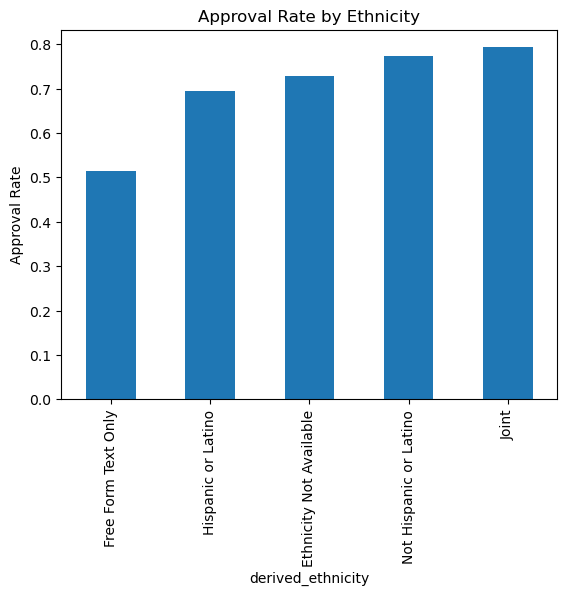

In [16]:
df.groupby("derived_ethnicity")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Ethnicity")
plt.show()

**Approval Rate by Ethnicity**

Approval rates differ across ethnicity groups, with "Not Hispanic or Latino" and "Joint" categories showing higher approval rates compared to "Hispanic or Latino" and "Free Form Text Only". The "Joint" category again reflects applications with multiple applicants, which may lead to stronger financial qualifications and therefore higher approval rates. The lower approval rate observed for the "Free Form Text Only" group may be due to incomplete or non-standard reporting of ethnicity, which can affect both data quality and interpretation. These differences suggest that ethnicity-related disparities may exist in the dataset and should be carefully examined in further analysis.

In [17]:
df.groupby("derived_sex")["target"].mean()

derived_sex
Female               0.707112
Joint                0.816700
Male                 0.735659
Sex Not Available    0.733781
Name: target, dtype: float64

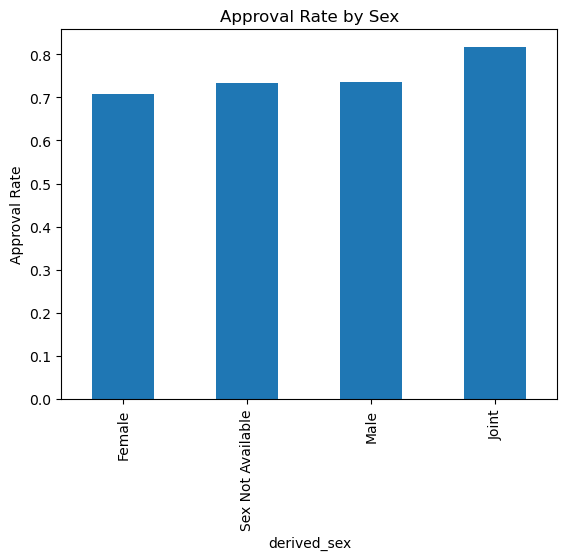

In [18]:
df.groupby("derived_sex")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Sex")
plt.show()

**Approval Rate by Sex**

Approval rates across sex categories appear relatively similar, with only modest differences between male and female applicants. However, the "Joint" category again shows a higher approval rate, likely reflecting the presence of multiple applicants and potentially stronger combined financial profiles. The "Sex Not Available" group also appears, which may indicate missing or unreported information. This highlights potential data quality limitations that should be considered when interpreting results. Overall, compared to race and ethnicity, disparities across sex appear less pronounced in the raw data.

**Examining Control Variables**

To better understand whether observed disparities in approval rates are driven by legitimate financial factors, we examine key control variables such as income and debt-to-income (DTI) ratio across different racial groups. These variables are commonly used in lending decisions and reflect applicants’ financial capacity and risk.

By analyzing these factors, we aim to distinguish whether differences in approval rates are due to underlying financial characteristics or whether disparities persist even after accounting for these variables, which may indicate potential bias.

In [19]:
df.groupby("derived_race").agg({
    "income": "mean",
    "target": "mean"
})

,income,target
derived_race,,
2 or more minority races,2478.580259,0.619721
American Indian or Alaska Native,189.579381,0.629659
Asian,223.784283,0.787293
Black or African American,312.503972,0.633432
Free Form Text Only,117.999535,0.410526
Joint,186.673286,0.804574
Native Hawaiian or Other Pacific Islander,136.327801,0.613013
Race Not Available,169.927906,0.722384
White,163.145612,0.781921


**Comparing Approval Rates and Income Across Racial Groups**

The results show clear differences in approval rates across racial groups. For example, White and Asian applicants have relatively high approval rates (around 78–79%), while Black or African American applicants have a lower approval rate (around 63%).

Interestingly, these differences are not fully explained by income levels. In particular, the Black or African American group has the highest average income among all groups, yet its approval rate remains lower than that of White and Asian applicants. This suggests that income alone does not fully account for the observed disparities.

However, these results should be interpreted with caution. At this stage, we have not yet controlled for other important factors such as debt-to-income ratio, loan type, or other risk-related variables. Therefore, while the findings indicate the presence of disparities in the data, they do not necessarily imply bias.

Further analysis is needed to determine whether these differences are driven by legitimate financial factors or potential unfair treatment.

In [20]:
import numpy as np

def dti_to_numeric(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    if "<20%" in x:
        return 15
    elif "20%-<30%" in x:
        return 25
    elif "30%-<36%" in x:
        return 33
    elif "36" in x and "%" in x:
        return 36
    elif "50%-60%" in x:
        return 55
    elif ">60%" in x:
        return 65
    
    try:
        return float(x)
    except:
        return np.nan

**Handling and Simplifying Debt-to-Income Ratio (DTI)**

The original `debt_to_income_ratio` variable contains a mixture of formats, including both numeric values (e.g., 40.0, 45.0) and categorical ranges (e.g., "20%-<30%", "50%-60%"). This makes the data inconsistent and difficult to interpret directly, especially when comparing financial risk across groups.

To improve readability and analysis, we aim to group DTI into a small number of meaningful categories (e.g., <30%, 30–40%, 40–50%, etc.) and examine how these risk levels relate to approval rates.

However, in order to classify values using conditional statements (e.g., `if x < 30`), the data must first be in numeric form. Since the original variable includes both numbers and string-based ranges, a direct conversion to numeric would result in many values being converted to `NaN`, causing significant information loss.

To address this, we first map each range-based value to a representative numeric value (e.g., "30%-<36%" → 33). This step allows us to preserve the relative meaning of each range while converting all values into a consistent numeric format.

Once the data is standardized, we can then apply conditional logic to group observations into clearly defined DTI categories, enabling a more structured and interpretable analysis of financial risk and approval outcomes.

In [21]:
df["dti_numeric"] = df["debt_to_income_ratio"].apply(dti_to_numeric)

In [22]:
def simplify_dti(x):
    if pd.isna(x):
        return "Missing"
    
    if x < 30:
        return "<30%"
    elif x < 40:
        return "30-40%"
    elif x < 50:
        return "40-50%"
    elif x < 60:
        return "50-60%"
    else:
        return ">60%"

In [23]:
df["dti_group"] = df["dti_numeric"].apply(simplify_dti)

In [24]:
result = df.groupby(["derived_race", "dti_group"])["target"].mean().unstack()
result["overall_approval_rate"] = df.groupby("derived_race")["target"].mean()
result

dti_group,30-40%,40-50%,50-60%,<30%,>60%,Missing,overall_approval_rate
derived_race,,,,,,,
2 or more minority races,0.771525,0.795628,0.563624,0.558792,0.054297,0.582692,0.619721
American Indian or Alaska Native,0.767349,0.794302,0.556998,0.592345,0.046657,0.612577,0.629659
Asian,0.901438,0.895854,0.543929,0.841224,0.060951,0.756799,0.787293
Black or African American,0.755345,0.782179,0.590037,0.594256,0.056617,0.636897,0.633432
Free Form Text Only,0.628895,0.711221,0.350365,0.447183,0.008532,0.195122,0.410526
Joint,0.879518,0.878215,0.692835,0.835759,0.138678,0.756180,0.804574
Native Hawaiian or Other Pacific Islander,0.771999,0.786864,0.591261,0.604984,0.056678,0.600861,0.613013
Race Not Available,0.831719,0.827935,0.587697,0.759695,0.075564,0.728195,0.722384
White,0.874311,0.867662,0.628882,0.826858,0.096396,0.751143,0.781921


**Comparing Approval Rates and debt_to_income_rate  Across Racial Groups**

To better understand whether approval disparities are driven by financial risk, we examine approval rates across racial groups within the same DTI categories.

Overall, approval rates decrease as DTI increases, which is expected since higher debt-to-income ratios indicate higher financial risk. This suggests that lending decisions are at least partially aligned with risk-based factors.

However, even within the same DTI group, differences across racial groups still exist. In particular, White applicants consistently show relatively high approval rates across most DTI categories. For example, in the 30–40% and 40–50% DTI ranges, White applicants maintain approval rates close to or above 85%, which are among the highest across all groups.

In contrast, some groups, such as Black or African American and "2 or more minority races," tend to have lower approval rates within the same DTI categories. This suggests that differences in financial risk alone do not fully explain the observed disparities.

Overall, these results indicate that while DTI explains part of the variation in approval rates, disparities across racial groups persist even after controlling for financial risk. This may suggest the presence of unequal treatment or unobserved factors, and warrants further investigation in the modeling stage.

### Modeling  

#### 5.	Feature selection

**Model Design and Feature Selection**

To evaluate both predictive performance and fairness, we construct two models with different feature sets.

---

**Model A: Baseline Model (Excluding Protected Attributes)**

Model A includes only financial and loan-related variables that are commonly used in lending decisions:

- **1. income**: Represents the applicant’s repayment ability. Higher income generally indicates lower default risk.

- **2. ebt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant’s debt burden relative to income.

- **3. loan_term**: Indicates the duration of the loan. Longer terms may be associated with different risk profiles.

- **4. loan_type**: Different loan types (e.g., conventional vs. FHA) have different approval standards and risk characteristics.

- **5. loan_purpose**: Distinguishes between purposes such as home purchase or refinancing, which may affect approval likelihood.

- **6. applicant_credit_score_type**: Indicates the type of credit scoring model used for the applicant. Although it is not the numeric credit score itself, it can still serve as a proxy for credit evaluation differences and may help explain variation in approval patterns or pricing decisions.

- **7. tract_minority_population_percent**: Measures the share of minority residents in the applicant’s census tract. This variable can serve as a neighborhood-level proxy for demographic context and is useful for analyzing potential geographic or structural fairness issues beyond individual protected attributes.

- **8. combined_loan_to_value_ratio**:  Captures the ratio between the loan amount and the property value, directly reflecting the borrower’s leverage level. A higher CLTV indicates that the borrower is financing a larger portion of the property, which typically implies higher credit risk and plays a critical role in underwriting decisions.

- **9. property_value**: Represents the estimated value of the property used as collateral. This feature provides context for the scale of the loan and helps the model assess whether the requested loan amount is reasonable relative to the asset value.


We retain combined **combined_loan-to-value ratio (CLTV)** and **property_value** while excluding **loan_amount** to avoid redundancy. CLTV captures the borrower’s leverage and directly reflects credit risk, while property_value provides contextual information about the scale of the underlying asset. Together, they allow the model to distinguish between relative risk and absolute transaction size, leading to clearer interpretation and more reliable fairness analysis.

We exclude **interest_rate** and **rate_spread** from the main model because they are closely tied to pricing outcomes and may introduce data leakage, as they are not strictly determined before the approval decision. We also exclude **state_code** to avoid capturing broad geographic patterns that may reflect structural or historical disparities rather than individual financial risk. These variables are instead used in post-model analysis, where **interest_rate** and **rate_spread** support pricing fairness evaluation, and **state_code** is used to assess robustness and geographic disparities.

These variables are included because they provide meaningful and justifiable information about financial risk and lending conditions. Model A represents a fairness-aware design that does not directly use protected attributes in decision-making.

---
**Model B: Extended Model (Including Protected Attribute)**

Model B includes all features from Model A, with the addition of:

- **derived_race**: A protected attribute representing the applicant’s race.

This model is not intended for deployment but is used as an analytical tool to examine whether including race improves predictive performance and how it affects fairness. The reason of not adding sex is because we didn't observe the disparity in raw data. 

---

**Purpose of Comparing Two Models**

The goal of constructing these two models is to analyze the trade-off between accuracy and fairness. By comparing Model A and Model B, we can evaluate:

- Whether including race significantly improves predictive accuracy
- Whether it leads to increased disparities across racial groups

In particular, we focus on group-based error metrics such as:

- **False Positive Rate (FPR)**: The rate at which applicants who should be rejected are incorrectly approved
- **False Negative Rate (FNR)**: The rate at which applicants who should be approved are incorrectly rejected

By comparing FPR and FNR across racial groups, we can assess whether the model produces unequal error patterns, which may indicate potential bias.


In [25]:
from sklearn.model_selection import train_test_split

#features without race 
featuresA = [
    "income",
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
    

]
#features with race 
featuresB= featuresA + ["derived_race"]
target = "target"

#### 6. Train-Test Split

We use the same train/test split for both models to ensure a fair comparison. Although Model A and Model B differ in the number of features, they are trained and evaluated on identical data. This allows us to isolate the effect of including the protected attribute and compare performance and fairness metrics more reliably.

**Model A (without race)**

In [26]:
# -----------------------------
# Step 0: define feature types
# -----------------------------
# IMPORTANT: loan_term moved from categorical -> numeric.
# It is a count of months (e.g., 360, 180, 240) — a real numeric quantity.
# Treating it as categorical exploded the one-hot matrix to 502 columns.
# As numeric, the matrix is ~30 columns and the full data fits in memory.
numeric_features_A = [
    "income",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value",
    "loan_term"
]

categorical_features_A = [
    "dti_group",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type"
]

# -----------------------------
# Step 1: clean dtypes in df
# -----------------------------
for col in numeric_features_A:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_features_A:
    df[col] = df[col].astype("string")

# for Model B
df["derived_race"] = df["derived_race"].astype("string")

# -----------------------------
# Step 2: build X and y
# -----------------------------
X_A = df[featuresA].copy()
y = df[target].astype(int).copy()

# -----------------------------
# Step 3: train/test split
# -----------------------------
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# optional check
print(X_train_A.dtypes)
print(X_test_A.dtypes)

n_train = X_train_A.shape[0]
n_test  = X_test_A.shape[0]
total   = n_train + n_test
pct_train = 100 * n_train / total
pct_test  = 100 * n_test  / total

print(
    f"Model A → Train: {X_train_A.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test_A.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)


income                                      float64
dti_group                            string[python]
loan_term                                   float64
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
dtype: object
income                                      float64
dti_group                            string[python]
loan_term                                   float64
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
dtype: object
Model A → Train: (6929421, 9) (6,929

**Model B (without race)**

In [27]:
# Build X
X_B = df[featuresB].copy()

# Use SAME split indices
X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B  = X_B.loc[X_test_A.index].copy()

# Clean dtypes in X_B using same logic as X_A
for col in numeric_features_A:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col]  = pd.to_numeric(X_test_B[col], errors="coerce")

for col in categorical_features_A:
    X_train_B[col] = X_train_B[col].astype("string")
    X_test_B[col]  = X_test_B[col].astype("string")

# Clean derived
X_train_B["derived_race"] = X_train_B["derived_race"].astype("string")
X_test_B["derived_race"]  = X_test_B["derived_race"].astype("string")


# optional check
print(X_train_B.dtypes)
print(X_test_B.dtypes)

print(
    f"Model B → Train: {X_train_B.shape}, "
    f"Test: {X_test_B.shape}"
)

income                                      float64
dti_group                            string[python]
loan_term                                   float64
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
derived_race                         string[python]
dtype: object
income                                      float64
dti_group                            string[python]
loan_term                                   float64
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float6

In [28]:
import numpy as np
import pandas as pd

def sklearn_safe(df_in):
    """Convert pandas StringDtype columns -> object with np.nan, and
    any pd.NA remnants in numerics -> np.nan. sklearn needs this."""
    df_out = df_in.copy()
    for col in df_out.columns:
        s = df_out[col]
        if pd.api.types.is_string_dtype(s) and not pd.api.types.is_object_dtype(s):
            df_out[col] = s.astype(object).where(s.notna(), np.nan)
        elif s.dtype == object:
            df_out[col] = s.where(s.notna(), np.nan)
    return df_out

X_train_A = sklearn_safe(X_train_A)
X_test_A  = sklearn_safe(X_test_A)
X_train_B = sklearn_safe(X_train_B)
X_test_B  = sklearn_safe(X_test_B)

#### 7.  logistic regression (Model A vs Model B)

**Model A**

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 4: preprocessing for Model A
# -----------------------------
numeric_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_A, numeric_features_A),
        ("cat", categorical_transformer_A, categorical_features_A)
    ]
)

# -----------------------------
# Step 5: Logistic Regression pipeline
# -----------------------------
model_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 6: fit model
# -----------------------------
model_A.fit(X_train_A, y_train)

# -----------------------------
# Step 7: predictions
# -----------------------------
y_train_pred_A = model_A.predict(X_train_A)
y_test_pred_A = model_A.predict(X_test_A)

# -----------------------------
# Step 8: evaluation
# -----------------------------
train_acc_A = accuracy_score(y_train, y_train_pred_A)
test_acc_A = accuracy_score(y_test, y_test_pred_A)

print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8257
Test Accuracy:  0.8257


In [30]:
# Build result_A for fairness analysis (mirrors result_B / result_gbt pattern)
pred_A = model_A.predict(X_test_A)

result_A = X_test_A.copy()
result_A["y_true"] = y_test.values
result_A["y_pred"] = pred_A
result_A["race"]   = df.loc[X_test_A.index, "derived_race"].astype("string")


def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

fairness_A = result_A.groupby("race", dropna=False).apply(compute_metrics)
fairness_A.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4362.0,0.7948,0.5356,0.0462,0.7678
American Indian or Alaska Native,12627.0,0.8245,0.5919,0.0369,0.7559
Asian,104846.0,0.8792,0.5354,0.0282,0.8641
Black or African American,153066.0,0.8161,0.5855,0.0497,0.7532
Free Form Text Only,444.0,0.5923,0.3571,0.0562,0.7635
Joint,37528.0,0.9084,0.6473,0.0284,0.8511
Native Hawaiian or Other Pacific Islander,4205.0,0.7700,0.5053,0.0665,0.7660
Race Not Available,304530.0,0.8571,0.6135,0.0493,0.7941
White,1110748.0,0.8934,0.6201,0.0304,0.8411


**Model B**

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 1: build X for Model B
# -----------------------------
X_B = df[featuresB].copy()

# Use the same split indices as Model A
X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B  = X_B.loc[X_test_A.index].copy()

# -----------------------------
# Step 2: define feature types for Model B
# -----------------------------
numeric_features_B = numeric_features_A.copy()

categorical_features_B = categorical_features_A + ["derived_race"]

# optional safety: enforce dtypes again
for col in numeric_features_B:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col]  = pd.to_numeric(X_test_B[col], errors="coerce")

for col in categorical_features_B:
    X_train_B[col] = X_train_B[col].astype("string")
    X_test_B[col]  = X_test_B[col].astype("string")

# -----------------------------
# Step 3: preprocessing for Model B
# -----------------------------
numeric_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_B, numeric_features_B),
        ("cat", categorical_transformer_B, categorical_features_B)
    ]
)

# -----------------------------
# Step 4: Logistic Regression pipeline
# -----------------------------
model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 5: fit Model B
# -----------------------------
X_train_B = sklearn_safe(X_train_B)
X_test_B  = sklearn_safe(X_test_B)
model_B.fit(X_train_B, y_train)

# -----------------------------
# Step 6: predictions
# -----------------------------
y_train_pred_B = model_B.predict(X_train_B)
y_test_pred_B = model_B.predict(X_test_B)

# -----------------------------
# Step 7: evaluation
# -----------------------------
train_acc_B = accuracy_score(y_train, y_train_pred_B)
test_acc_B = accuracy_score(y_test, y_test_pred_B)

print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8270
Test Accuracy:  0.8269


In [32]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B = model_B.predict(X_test_B)

# Combine results
result_B = X_test_B.copy()
result_B["y_true"] = y_test.values
result_B["y_pred"] = pred_B
result_B["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B = result_B.groupby("race", dropna=False).apply(compute_metrics)

fairness_B.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4362.0,0.7531,0.4662,0.0710,0.7788
American Indian or Alaska Native,12627.0,0.7704,0.5095,0.0742,0.7633
Asian,104846.0,0.8909,0.5605,0.0201,0.8652
Black or African American,153066.0,0.7754,0.5269,0.0800,0.7556
Free Form Text Only,444.0,0.5360,0.3045,0.1180,0.7703
Joint,37528.0,0.9160,0.6647,0.0233,0.8518
Native Hawaiian or Other Pacific Islander,4205.0,0.7301,0.4442,0.0935,0.7727
Race Not Available,304530.0,0.8415,0.5776,0.0572,0.7984
White,1110748.0,0.9058,0.6481,0.0224,0.8412


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [33]:
fairness_A_renamed = fairness_A.rename(columns={
    "FPR": "FPR_A",
    "FNR": "FNR_A",
    "Accuracy": "Accuracy_A",
    "Approval_Rate": "Approval_Rate_A"
}).drop(columns=["Count"])

fairness_B_renamed = fairness_B.rename(columns={
    "FPR": "FPR_B",
    "FNR": "FNR_B",
    "Accuracy": "Accuracy_B",
    "Approval_Rate": "Approval_Rate_B"
}).drop(columns=["Count"])

comparison_lr = fairness_A_renamed.join(fairness_B_renamed)
comparison_lr.round(4)

,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.7948,0.5356,0.0462,0.7678,0.7531,0.4662,0.0710,0.7788
American Indian or Alaska Native,0.8245,0.5919,0.0369,0.7559,0.7704,0.5095,0.0742,0.7633
Asian,0.8792,0.5354,0.0282,0.8641,0.8909,0.5605,0.0201,0.8652
Black or African American,0.8161,0.5855,0.0497,0.7532,0.7754,0.5269,0.0800,0.7556
Free Form Text Only,0.5923,0.3571,0.0562,0.7635,0.5360,0.3045,0.1180,0.7703
Joint,0.9084,0.6473,0.0284,0.8511,0.9160,0.6647,0.0233,0.8518
Native Hawaiian or Other Pacific Islander,0.7700,0.5053,0.0665,0.7660,0.7301,0.4442,0.0935,0.7727
Race Not Available,0.8571,0.6135,0.0493,0.7941,0.8415,0.5776,0.0572,0.7984
White,0.8934,0.6201,0.0304,0.8411,0.9058,0.6481,0.0224,0.8412


In [34]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8257
Test Accuracy:  0.8257
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8270
Test Accuracy:  0.8269


**Interpretation of Results**

While the inclusion of race in Model B leads to a slight improvement in overall accuracy, this improvement does not translate into better outcomes for all groups.

In particular, for groups such as American Indian or Alaska Native and Black or African American applicants, approval rates decrease noticeably after including race. At the same time, their false negative rates (FNR) increase, indicating that more qualified applicants from these groups are incorrectly denied.

This suggests that although the model becomes slightly more accurate overall, it may do so at the expense of certain minority groups. In other words, the gain in predictive performance is accompanied by a worsening of error distribution across groups.

This highlights an important trade-off: improving overall accuracy does not necessarily improve fairness, and in some cases may even exacerbate disparities.

#### 8. Gradient boost tree (Model A vs Model B)

**Model A**

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step: Gradient Boosting pipeline (Model A)
# -----------------------------
model_A_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# Fit model
# -----------------------------

X_train_A = sklearn_safe(X_train_A)
X_test_A  = sklearn_safe(X_test_A)
model_A_gbt.fit(X_train_A, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_gbt = model_A_gbt.predict(X_train_A)
y_test_pred_gbt = model_A_gbt.predict(X_test_A)

# -----------------------------
# Accuracy
# -----------------------------
train_acc_gbt = accuracy_score(y_train, y_train_pred_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_pred_gbt)

print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")


========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8454
Test Accuracy:  0.8454


In [36]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_gbt = model_A_gbt.predict(X_test_A)

# ---------- Combine results ----------
result_gbt = X_test_A.copy()
result_gbt["y_true"] = y_test.values
result_gbt["y_pred"] = pred_gbt

result_gbt["race"] = df.loc[X_test_A.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_gbt = result_gbt.groupby("race", dropna=False).apply(compute_metrics)
fairness_gbt.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4362.0,0.7675,0.4530,0.0396,0.8033
American Indian or Alaska Native,12627.0,0.7797,0.4765,0.0397,0.7973
Asian,104846.0,0.8772,0.5048,0.0224,0.8752
Black or African American,153066.0,0.7831,0.4952,0.0494,0.7866
Free Form Text Only,444.0,0.6059,0.3647,0.0337,0.7680
Joint,37528.0,0.8996,0.5792,0.0229,0.8688
Native Hawaiian or Other Pacific Islander,4205.0,0.7536,0.4455,0.0562,0.7952
Race Not Available,304530.0,0.8587,0.5689,0.0299,0.8205
White,1110748.0,0.8785,0.5481,0.0294,0.8576


**Model B**

In [37]:
# -----------------------------
# Gradient Boosting pipeline
# -----------------------------
model_B_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", GradientBoostingClassifier(
        n_estimators=60,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# fit model
# -----------------------------
X_train_B = sklearn_safe(X_train_B)
X_test_B  = sklearn_safe(X_test_B)
model_B_gbt.fit(X_train_B, y_train)

# -----------------------------
# predictions
# -----------------------------
y_train_pred_B_gbt = model_B_gbt.predict(X_train_B)
y_test_pred_B_gbt = model_B_gbt.predict(X_test_B)

# -----------------------------
# evaluation
# -----------------------------
train_acc_B_gbt = accuracy_score(y_train, y_train_pred_B_gbt)
test_acc_B_gbt = accuracy_score(y_test, y_test_pred_B_gbt)

print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8393
Test Accuracy:  0.8391


In [38]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B_gbt = model_B_gbt.predict(X_test_B)

# ---------- Combine results ----------
result_B_gbt = X_test_B.copy()
result_B_gbt["y_true"] = y_test.values
result_B_gbt["y_pred"] = pred_B_gbt
result_B_gbt["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B_gbt = result_B_gbt.groupby("race", dropna=False).apply(compute_metrics)

fairness_B_gbt.round(4)

,Approval_Rate,FPR,FNR,Accuracy
race,,,,
2 or more minority races,0.7774,0.4813,0.0411,0.7916
American Indian or Alaska Native,0.7874,0.4964,0.0392,0.7901
Asian,0.8811,0.5265,0.0233,0.8699
Black or African American,0.7857,0.5070,0.0521,0.7806
Free Form Text Only,0.6149,0.3797,0.0337,0.7590
Joint,0.9031,0.6011,0.0238,0.8638
Native Hawaiian or Other Pacific Islander,0.7612,0.4667,0.0569,0.7867
Race Not Available,0.8683,0.6031,0.0298,0.8111
White,0.8988,0.6072,0.0200,0.8521


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [39]:
fairness_gbt_A_renamed = fairness_gbt.rename(columns={
    "FPR": "FPR_A_GBT",
    "FNR": "FNR_A_GBT",
    "Accuracy": "Accuracy_A_GBT",
    "Approval_Rate": "Approval_Rate_A_GBT"
}).drop(columns=["Count"], errors="ignore")

fairness_gbt_B_renamed = fairness_B_gbt.rename(columns={
    "FPR": "FPR_B_GBT",
    "FNR": "FNR_B_GBT",
    "Accuracy": "Accuracy_B_GBT",
    "Approval_Rate": "Approval_Rate_B_GBT"
}).drop(columns=["Count"], errors="ignore")

comparison_gbt = fairness_gbt_A_renamed.join(fairness_gbt_B_renamed)
comparison_gbt.round(4)

,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.7675,0.4530,0.0396,0.8033,0.7774,0.4813,0.0411,0.7916
American Indian or Alaska Native,0.7797,0.4765,0.0397,0.7973,0.7874,0.4964,0.0392,0.7901
Asian,0.8772,0.5048,0.0224,0.8752,0.8811,0.5265,0.0233,0.8699
Black or African American,0.7831,0.4952,0.0494,0.7866,0.7857,0.5070,0.0521,0.7806
Free Form Text Only,0.6059,0.3647,0.0337,0.7680,0.6149,0.3797,0.0337,0.7590
Joint,0.8996,0.5792,0.0229,0.8688,0.9031,0.6011,0.0238,0.8638
Native Hawaiian or Other Pacific Islander,0.7536,0.4455,0.0562,0.7952,0.7612,0.4667,0.0569,0.7867
Race Not Available,0.8587,0.5689,0.0299,0.8205,0.8683,0.6031,0.0298,0.8111
White,0.8785,0.5481,0.0294,0.8576,0.8988,0.6072,0.0200,0.8521


In [40]:
print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8454
Test Accuracy:  0.8454
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8393
Test Accuracy:  0.8391


**Interpretation of GBT Results**

The gradient-boosted tree model achieves higher accuracy and lower error rates (FPR and FNR) compared to logistic regression.

This improvement can be explained by the flexibility of the GBT model. Unlike logistic regression, which assumes a linear relationship, gradient boosting is able to capture complex, non-linear interactions between features. By iteratively correcting prediction errors and combining multiple weak learners, the model can better fit the underlying patterns in the data.  


#### 9. Comparison Across Modeling Approaches

**Why We Use Multiple Models?**

We use both logistic regression and gradient-boosted trees to ensure that our results are robust and not dependent on a single modeling approach.

Logistic regression is simple and interpretable, but it assumes a linear relationship between features and the outcome. In contrast, gradient-boosted trees are more flexible and can capture complex, non-linear patterns by iteratively correcting prediction errors and combining multiple weak models into a stronger one.

By comparing the results from both models, we can check whether our findings, especially those related to fairness are consistent. If both models lead to similar conclusions, we can be more confident that the results reflect real patterns in the data rather than artifacts of a specific model.

**Performance from Different Approaches**

To summarize the results across different modeling approaches, we present the comparison tables below.

In [41]:
print("Logistic Regression")
display(comparison_lr)

print("Gradient Boosted Tree")
display(comparison_gbt)

Logistic Regression


,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.794819,0.535585,0.046228,0.767767,0.753095,0.466224,0.071006,0.778771
American Indian or Alaska Native,0.824503,0.591854,0.036901,0.755920,0.770413,0.509546,0.074182,0.763285
Asian,0.879175,0.535400,0.028165,0.864144,0.890888,0.560467,0.020052,0.865212
Black or African American,0.816145,0.585543,0.049669,0.753211,0.775391,0.526880,0.080001,0.755615
Free Form Text Only,0.592342,0.357143,0.056180,0.763514,0.536036,0.304511,0.117978,0.770270
Joint,0.908442,0.647324,0.028424,0.851071,0.915983,0.664705,0.023262,0.851844
Native Hawaiian or Other Pacific Islander,0.770036,0.505296,0.066538,0.765993,0.730083,0.444237,0.093462,0.772652
Race Not Available,0.857085,0.613497,0.049307,0.794070,0.841454,0.577632,0.057162,0.798352
White,0.893439,0.620149,0.030417,0.841077,0.905800,0.648124,0.022407,0.841247


Gradient Boosted Tree


,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.767538,0.452955,0.039571,0.803301,0.777396,0.481303,0.041050,0.791609
American Indian or Alaska Native,0.779678,0.476453,0.039682,0.797260,0.787440,0.496394,0.039176,0.790132
Asian,0.877182,0.504762,0.022437,0.875160,0.881140,0.526550,0.023285,0.869866
Black or African American,0.783081,0.495178,0.049390,0.786628,0.785694,0.506971,0.052118,0.780565
Free Form Text Only,0.605856,0.364662,0.033708,0.768018,0.614865,0.379699,0.033708,0.759009
Joint,0.899648,0.579171,0.022865,0.868818,0.903139,0.601067,0.023824,0.863782
Native Hawaiian or Other Pacific Islander,0.753627,0.445483,0.056154,0.795244,0.761237,0.466667,0.056923,0.786683
Race Not Available,0.858736,0.568926,0.029892,0.820468,0.868302,0.603111,0.029788,0.811053
White,0.878548,0.548057,0.029372,0.857604,0.898784,0.607176,0.019970,0.852075


In [42]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")


print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8257
Test Accuracy:  0.8257
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8270
Test Accuracy:  0.8269
========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8454
Test Accuracy:  0.8454
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8393
Test Accuracy:  0.8391


Across models, Gradient Boosting consistently achieves higher accuracy than Logistic Regression, improving overall predictive performance. However, this performance gain does not eliminate disparities across racial groups.

Comparing Model A and Model B within each algorithm, the inclusion of race does not lead to substantial improvements in accuracy for either Logistic Regression or Gradient Boosting. In some cases, it also shifts approval rates and error distributions across groups, indicating that the effect of race is more visible in group-level outcomes than in overall performance.

Importantly, disparities in approval rates, false positive rates (FPR), and false negative rates (FNR) persist under both models. While Gradient Boosting slightly stabilizes some metrics, it does not fundamentally resolve fairness issues. This suggests that the observed disparities are not driven solely by model choice or the explicit inclusion of race, but are likely embedded in the underlying data through correlated features.

Overall, increasing model complexity improves accuracy but does not necessarily improve fairness, highlighting the persistent trade-off between predictive performance and equitable outcomes.

#### 10. Interpretation and Insights

**Interpretation of Remaining Disparities**

The pre-modeling analysis reveals that approval rates differ across racial groups, and these disparities cannot be explained by income alone. We further examine whether key risk-related variables, such as debt-to-income ratio (DTI), can account for these differences. However, even after incorporating DTI into the model, disparities persist, indicating that risk factors alone do not fully explain the observed patterns.

When comparing models with and without race, we observe that including race leads to some changes in group-level metrics, indicating that race does have some influence on model predictions. However, these changes do not mitigate disparities and, in some cases, even worsen error rates for certain minority groups. More importantly, the inclusion of race is still insufficient to fully explain the disparities observed in the raw data.

Taken together, these findings suggest that neither income, DTI, nor the explicit inclusion of race is sufficient to account for the observed differences in outcomes. This points to the presence of other variables in the dataset that may act as proxies for race, capturing underlying structural patterns. Therefore, further analysis is needed to identify and evaluate these potential proxy variables.

**Modeling Strategy and Key Insights**

Based on the comparison across logistic regression and gradient-boosted tree models, we define the role of each model for the subsequent analysis.

Model A is treated as the primary model because it excludes the protected attribute and better reflects a fairness-aware design. This model is used for in-depth analysis, including interpretability (LIME/SHAP), fairness evaluation, and robustness checks.

Model B, which includes the protected attribute, is used as a diagnostic comparison model. The results show that including race does not improve predictive performance or mitigate disparities. Instead, it mainly shifts error patterns across groups, suggesting that the model does not rely heavily on the explicit race variable.

This distinction allows us to evaluate both model performance and fairness while highlighting that removing protected attributes alone is insufficient to eliminate disparities. Instead, it emphasizes the role of correlated variables and potential proxies in driving the observed patterns.

### Transparency (Model Explainability)

Transparency

These features help explain why the model makes certain decisions and reflect core financial logic.

**1. income**: Represents the applicant’s repayment ability. Higher income generally indicates lower default risk.

**2. debt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant’s debt burden relative to income.

**3. combined loan-to-value ratio (CLTV)**: Measures leverage relative to property value, indicating financial risk exposure.

**4. loan_amount**: Captures the size of the loan. Larger loans may carry higher financial risk.

**5. loan_term:** Indicates the duration of the loan. Longer terms may affect repayment stability and risk exposure.

👉 These variables are typically highlighted in:
•	SHAP / LIME explanations
•	Feature importance analysis
•	Decision interpretation

### Fairness Evaluation

Fairness

These features are used to evaluate whether model outcomes differ systematically across groups and to identify potential sources of bias.

1. derived_race / derived_ethnicity / derived_sex: Protected attributes used to define groups for fairness evaluation (e.g., approval rate, FPR, FNR comparisons).
2. tract_minority_population_percent: A neighborhood-level proxy that may capture structural or geographic disparities correlated with race.
3. income: Helps assess whether differences in outcomes can be explained by repayment ability.
4. debt-to-income ratio (DTI group): A key risk factor used to evaluate whether disparities persist after controlling for financial risk.
5. combined loan-to-value ratio (CLTV): Captures leverage and financial exposure, allowing us to test whether risk-based factors explain group differences.
6. loan_type / loan_purpose: Control variables that help distinguish policy or product-related differences from potential bias.

👉 These variables are typically used in:  
• Group fairness metrics (Approval Rate, FPR, FNR)  
• Disparity decomposition (what explains vs what remains)  
• Intersectional analysis (e.g., race × income)

### Robustness Analysis

Robustness

These features are used to evaluate whether the model’s performance and fairness remain stable across different conditions and data slices.

1. state_code: Captures geographic variation, useful for testing whether model performance shifts across regions.
2. loan_type / loan_purpose: Allows evaluation across different loan categories to ensure the model generalizes beyond a specific segment.
3. income / DTI / CLTV: Used to create slices (e.g., low vs high risk borrowers) to test whether performance varies across risk levels.
4. tract_minority_population_percent: Enables testing whether model behavior is stable across different neighborhood compositions.
5. property_value: Helps assess whether model performance changes across different asset levels or loan scales.

👉 These variables are typically used in:  
• Slice-based evaluation (performance by subgroup)  
• Distribution shift detection (e.g., PSI, KS test)  
• Stability checks (train vs test vs subgroup comparison)

### Privacy & Safety 

Privacy & Safety

These features are relevant when evaluating potential privacy risks and model vulnerability, particularly in relation to sensitive or proxy information.

1. derived_race / derived_ethnicity / derived_sex: Sensitive attributes that require careful handling to avoid misuse or unintended leakage.
2. tract_minority_population_percent: A proxy variable that may indirectly reveal protected characteristics, raising potential privacy concerns.
3. state_code: Geographic information that may contribute to re-identification risk when combined with other features.
4. applicant_credit_score_type: Reflects credit assessment structure and may be sensitive in terms of financial profiling.
5. income / CLTV / property_value: High-signal financial variables that can make individual records more identifiable in combination.

👉 These variables are typically used in:  
• Membership inference risk analysis  
• Proxy detection for sensitive attributes  
• Evaluating whether the model indirectly encodes protected information

## 10. Privacy & Safety — Adversarial ML Audit (Lecture 05)

This section applies the **Lecture 05 (ML Security & Abuse Pathways)** framework to our HMDA loan-approval model. We audit our gradient-boosted target model `model_A_gbt` against three attack classes from the NIST AI 100-2 taxonomy:

1. **PGD evasion** (deployment-time, integrity attack) — small, gradient-aligned perturbations to numerical features that try to flip predictions. Implemented as a **transfer attack** because GBT has no gradients of its own.
2. **Label-flip poisoning** (training-time, integrity + fairness attack) — corrupt training labels for a target race group, retrain, and watch model performance + fairness degrade.
3. **Membership inference** (deployment-time, privacy attack) — shadow-model pipeline that detects whether a record was in the training set.

**Polarity note.** In HMDA `target=1` means *approved* (favorable). AIR is computed on **selection rate** (approval rate ratio), which is what the 4/5ths rule applies to in lending.

### 10.1 Setup — race groups and helper functions

In [43]:
# Reuses df, model_A_gbt, X_train_A, X_test_A, y_train, y_test,
# preprocessor_A, numeric_features_A, categorical_features_A,
# sklearn_safe — all created earlier in this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Show available race groups so we can verify the constants below
print('derived_race value counts on the test set:')
print(df.loc[X_test_A.index, 'derived_race'].value_counts(dropna=False))
print()

# Edit these two if your dataset uses different group strings.
UNPRIV_GROUP = 'Black or African American'
PRIV_GROUP   = 'White'

race_test  = df.loc[X_test_A.index,  'derived_race'].values
race_train = df.loc[X_train_A.index, 'derived_race'].values

print(f'Privileged   group: {PRIV_GROUP}   (n_test = {(race_test == PRIV_GROUP).sum():,})')
print(f'Unprivileged group: {UNPRIV_GROUP} (n_test = {(race_test == UNPRIV_GROUP).sum():,})')


derived_race value counts on the test set:
derived_race
White                                        1110748
Race Not Available                            304530
Black or African American                     153066
Asian                                         104846
Joint                                          37528
American Indian or Alaska Native               12627
2 or more minority races                        4362
Native Hawaiian or Other Pacific Islander       4205
Free Form Text Only                              444
Name: count, dtype: Int64

Privileged   group: White   (n_test = 1,110,748)
Unprivileged group: Black or African American (n_test = 153,066)


In [44]:
# Helper functions adapted from the lecture's live coding session
THR = 0.5  # classification threshold

def selection_rate_by_group(y_pred_binary, groups):
    """Approval rate per race group (used for AIR in lending)."""
    return (
        pd.DataFrame({'pred': y_pred_binary, 'group': groups})
          .groupby('group')['pred'].mean()
    )

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR per race group: FP / (FP + TN), over truly-negative cases."""
    y_true = np.asarray(y_true)
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred'].mean()
    )

def air(rate_unpriv, rate_priv):
    """Adverse Impact Ratio = unprivileged / privileged.
    AIR < 0.80 violates the 4/5ths rule."""
    if rate_priv is None or rate_priv <= 0 or np.isnan(rate_priv):
        return np.nan
    return rate_unpriv / rate_priv


### 10.2 Clean-model fairness baseline

Baseline numbers from `model_A_gbt` on the un-perturbed test set. All attack outcomes below are compared against these values.

In [45]:
pred_gbt_clean = (model_A_gbt.predict_proba(X_test_A)[:, 1] >= THR).astype(int)

sel_b = selection_rate_by_group(pred_gbt_clean, race_test)
fpr_b = fpr_by_group(y_test, pred_gbt_clean, race_test)

BASELINE_SEL_UNPRIV = sel_b.get(UNPRIV_GROUP)
BASELINE_SEL_PRIV   = sel_b.get(PRIV_GROUP)
BASELINE_FPR_UNPRIV = fpr_b.get(UNPRIV_GROUP)
BASELINE_FPR_PRIV   = fpr_b.get(PRIV_GROUP)
BASELINE_AIR        = air(BASELINE_SEL_UNPRIV, BASELINE_SEL_PRIV)

print('=' * 64)
print('CLEAN MODEL BASELINE — Gradient Boosted Tree (model_A_gbt)')
print('=' * 64)
print(f'  Selection rate {UNPRIV_GROUP:30s}: {BASELINE_SEL_UNPRIV:.3f}')
print(f'  Selection rate {PRIV_GROUP:30s}: {BASELINE_SEL_PRIV:.3f}')
print(f'  AIR (selection rates)                             : {BASELINE_AIR:.3f}')
print(f'  FPR {UNPRIV_GROUP:35s}  : {BASELINE_FPR_UNPRIV:.3f}')
print(f'  FPR {PRIV_GROUP:35s}  : {BASELINE_FPR_PRIV:.3f}')
print(f'\nStored BASELINE_AIR = {BASELINE_AIR:.3f}  (compare attacks to this)')


CLEAN MODEL BASELINE — Gradient Boosted Tree (model_A_gbt)
  Selection rate Black or African American     : 0.783
  Selection rate White                         : 0.879
  AIR (selection rates)                             : 0.891
  FPR Black or African American            : 0.495
  FPR White                                : 0.548

Stored BASELINE_AIR = 0.891  (compare attacks to this)


### 10.3 Part A — PGD evasion (transfer attack on GBT)

**Threat model.** A gray-box adversary who can submit applications. They can't see GBT internals, but they can build a substitute (small linear model), run white-box PGD on it, and submit perturbed inputs to the deployed GBT API. Transferability of adversarial examples between linear and nonlinear classifiers is well-documented (Goodfellow 2015, Madry 2018).

**Steps:**
1. Train a substitute linear model on the same preprocessed feature space — internal attack tool only, **not** a deliverable model.
2. Run PGD on its numeric block, stepping in `sign(w)` and clipping to ε.
3. Score the perturbed inputs against `model_A_gbt`.
4. Sweep ε and record FPR by race + AIR.

**ε is in feature-σ units.** After preprocessing, numeric features have unit variance, so ε = 1.0 means the attacker can shift each numeric feature by up to one standard deviation.

In [46]:
# Step 1 — extract fitted preprocessor and classifier from model_A_gbt
fitted_pre_gbt = model_A_gbt.named_steps['preprocessor']
fitted_clf_gbt = model_A_gbt.named_steps['classifier']

n_num = len(numeric_features_A)
num_idx = np.arange(n_num)

def transform_dense_chunk(X_chunk):
    """Preprocess a chunk and return a dense float64 ndarray."""
    Z = fitted_pre_gbt.transform(X_chunk)
    if hasattr(Z, 'toarray'):
        Z = Z.toarray()
    return np.asarray(Z, dtype=float)

# Sanity check on a small slice
sample = X_test_A.iloc[:10_000]
Z_sample = transform_dense_chunk(sample)
p_pipe = model_A_gbt.predict_proba(sample)[:, 1]
p_raw  = fitted_clf_gbt.predict_proba(Z_sample)[:, 1]
print(f'Sanity check on 10k rows  : max |p_pipe - p_raw| = {np.max(np.abs(p_pipe - p_raw)):.2e}')
print(f'Numeric cols (perturbable): 0..{n_num - 1}  ({numeric_features_A})')

Sanity check on 10k rows  : max |p_pipe - p_raw| = 0.00e+00
Numeric cols (perturbable): 0..4  (['income', 'tract_minority_population_percent', 'combined_loan_to_value_ratio', 'property_value', 'loan_term'])


In [47]:
# Step 2 — train a substitute linear model on the FULL training set.
# Internal attack tool only — not a deliverable model.
# (Professor instruction: do not subsample. After moving loan_term to
# numeric, the preprocessed matrix is ~30 cols, so full-data fits.)
from sklearn.linear_model import LogisticRegression

print('Transforming full X_train_A through the fitted preprocessor...')
Z_train_full = transform_dense_chunk(X_train_A)
print(f'  Z_train_full shape: {Z_train_full.shape}  '
      f'(~{Z_train_full.nbytes / 1e9:.2f} GB)')

y_train_arr = (y_train.values if hasattr(y_train, 'values')
               else np.asarray(y_train))

substitute = LogisticRegression(max_iter=1000)
substitute.fit(Z_train_full, y_train_arr)

del Z_train_full  # free the matrix once the substitute is fit

print('\nSubstitute linear model trained (attack tool only).')
print(f'  Trained on    : {len(X_train_A):,} rows (FULL training set)')
print(f'  Coefs shape   : {substitute.coef_.shape}')


Transforming full X_train_A through the fitted preprocessor...
  Z_train_full shape: (6929421, 36)  (~2.00 GB)

Substitute linear model trained (attack tool only).
  Trained on    : 6,929,421 rows (FULL training set)
  Coefs shape   : (1, 36)


In [48]:
# Step 3 — PGD on substitute, evaluate against the GBT TARGET on the
# FULL test set (no subsampling). After moving loan_term to numeric the
# attack matrix is ~1.7M × ~30, which fits in memory.
print('Transforming FULL X_test_A through the fitted preprocessor...')
Z_attack = transform_dense_chunk(X_test_A)
print(f'Attack matrix Z_attack shape: {Z_attack.shape}  '
      f'(~{Z_attack.nbytes / 1e9:.2f} GB)')

y_attack    = (y_test.values if hasattr(y_test, 'values')
               else np.asarray(y_test))
race_attack = race_test  # already aligned to X_test_A

def pgd_transfer(substitute_lr, Z, num_cols, epsilon=1.0,
                 alpha=0.05, n_iter=40):
    coef    = substitute_lr.coef_[0]
    Z_adv   = Z.copy()
    sign_w  = np.zeros_like(coef)
    sign_w[num_cols] = np.sign(coef[num_cols])
    for _ in range(n_iter):
        Z_adv = Z_adv + alpha * sign_w[np.newaxis, :]
        Z_adv = np.clip(Z_adv, Z - epsilon, Z + epsilon)
    return Z_adv

epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    Z_adv = Z_attack if eps == 0.0 else pgd_transfer(
        substitute, Z_attack, num_idx, epsilon=eps, alpha=0.05, n_iter=40
    )
    pred_adv = (fitted_clf_gbt.predict_proba(Z_adv)[:, 1] >= THR).astype(int)

    sel = selection_rate_by_group(pred_adv, race_attack)
    fpr = fpr_by_group(y_attack, pred_adv, race_attack)

    s_u = sel.get(UNPRIV_GROUP, np.nan)
    s_p = sel.get(PRIV_GROUP,   np.nan)

    pgd_records.append({
        'epsilon'   : eps,
        'sel_unpriv': s_u,
        'sel_priv'  : s_p,
        'FPR_unpriv': fpr.get(UNPRIV_GROUP, np.nan),
        'FPR_priv'  : fpr.get(PRIV_GROUP,   np.nan),
        'AIR'       : air(s_u, s_p),
        'delta_AIR' : air(s_u, s_p) - BASELINE_AIR,
    })

df_pgd = pd.DataFrame(pgd_records)
print('\nPGD transfer attack on Model A GBT (FULL test set):')
print(df_pgd.round(3).to_string(index=False))


Transforming FULL X_test_A through the fitted preprocessor...
Attack matrix Z_attack shape: (1732356, 36)  (~0.50 GB)

PGD transfer attack on Model A GBT (FULL test set):
 epsilon  sel_unpriv  sel_priv  FPR_unpriv  FPR_priv   AIR  delta_AIR
    0.00       0.783     0.879       0.495     0.548 0.891      0.000
    0.25       0.139     0.232       0.036     0.055 0.599     -0.292
    0.50       0.146     0.198       0.038     0.049 0.735     -0.157
    0.75       0.018     0.037       0.009     0.019 0.489     -0.402
    1.00       0.021     0.039       0.011     0.021 0.548     -0.343
    1.50       0.021     0.036       0.011     0.019 0.596     -0.295
    2.00       0.014     0.017       0.007     0.009 0.806     -0.085


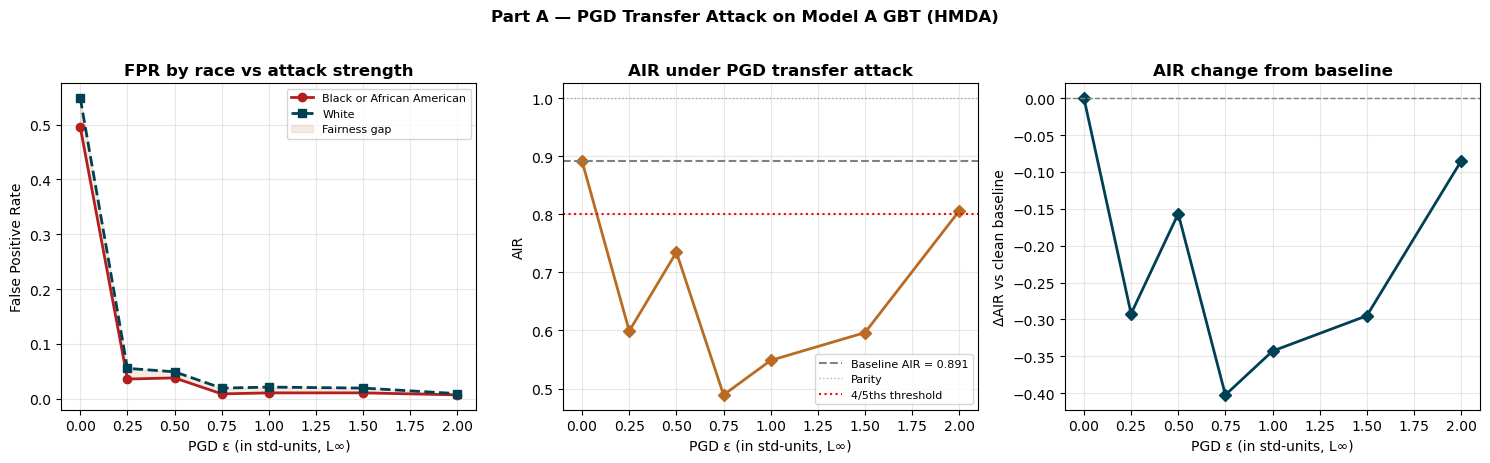

AIR crosses 0.80 at ε = 0.25


In [49]:
# Step 4 — visualize: 3-panel plot like the lecture
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_unpriv'],
        'o-', color='#B41E1E', lw=2, label=UNPRIV_GROUP)
ax.plot(df_pgd['epsilon'], df_pgd['FPR_priv'],
        's--', color='#004055', lw=2, label=PRIV_GROUP)
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_unpriv'], df_pgd['FPR_priv'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD ε (in std-units, L∞)')
ax.set_ylabel('False Positive Rate')
ax.set_title('FPR by race vs attack strength', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.6, label='Parity')
ax.axhline(0.8, color='red',  ls=':', lw=1.5, label='4/5ths threshold')
ax.set_xlabel('PGD ε (in std-units, L∞)')
ax.set_ylabel('AIR')
ax.set_title('AIR under PGD transfer attack', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AIR'], 'D-', color='#004055', lw=2)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('PGD ε (in std-units, L∞)')
ax.set_ylabel('ΔAIR vs clean baseline')
ax.set_title('AIR change from baseline', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Part A — PGD Transfer Attack on Model A GBT (HMDA)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print('AIR does not fall below 0.80 within the tested ε range.')


Reading the PGD plot. 
ε is in feature-σ units, so ε = 0.5 corresponds to roughly a half-σ nudge per numerical feature. Because GBT has no gradients, perturbations are crafted on a linear substitute and transferred to the deployed GBT. In our run, the transfer was effective: AIR crosses the 4/5ths threshold at ε = 0.25 (a quarter-σ shift) and reaches its worst value of 0.489 at ε = 0.75. This is direct evidence that an adversary submitting modestly-perturbed applications can push the deployed GBT into a 4/5ths-rule violation, even though the attacker has no white-box access to the GBT itself. The non-monotonic AIR curve across ε reflects the GBT decision boundary's local non-convexity along the substitute's gradient direction.

### 10.4 Part B — Label-flip poisoning attack

**Threat model.** Insider or compromised data pipeline flips a fraction of training labels for `UNPRIV_GROUP` from approved → denied. The model learns this group is less creditworthy than they are.

In [51]:
# Step 1 — use FULL training set (no subsampling). Professor instruction.
# After moving loan_term to numeric the feature space is small enough
# that retraining GBT on full data is tractable.
X_train_full    = sklearn_safe(X_train_A)
y_train_full    = (y_train.values if hasattr(y_train, 'values')
                   else np.asarray(y_train))
race_train_full = race_train  # already aligned to X_train_A

print(f'Full training set : {len(X_train_full):,} rows')
print(f'  {UNPRIV_GROUP:30s}: {(race_train_full == UNPRIV_GROUP).sum():,}')
print(f'  {PRIV_GROUP:30s}: {(race_train_full == PRIV_GROUP).sum():,}')


Full training set : 6,929,421 rows
  Black or African American     : 609,395
  White                         : 4,440,152


In [52]:
# Step 2 — label-flip helper + retraining loop on FULL data
def poison_label_flip(y_arr, race_arr, poison_rate=0.05,
                      target_race=UNPRIV_GROUP, seed=0):
    rng = np.random.default_rng(seed)
    y_p = np.asarray(y_arr).copy()
    candidates = np.where(
        (race_arr == target_race) & (y_p == 1)
    )[0]
    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_p[flip_idx] = 0
    return y_p, n_flip

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

def build_fresh_gbt_pipeline():
    """Same architecture as model_A_gbt — 100 estimators (matches main model)."""
    num_t = Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler',  StandardScaler())])
    cat_t = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot',  OneHotEncoder(handle_unknown='ignore'))])
    pre = ColumnTransformer([
        ('num', num_t, numeric_features_A),
        ('cat', cat_t, categorical_features_A),
    ])
    return Pipeline([
        ('preprocessor', pre),
        ('classifier', GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=3,
            random_state=42)),
    ])

poison_rates   = [0.00, 0.05, 0.10, 0.20, 0.30]
poison_records = []

baseline_auc = roc_auc_score(
    y_test, model_A_gbt.predict_proba(X_test_A)[:, 1]
)
print(f'Baseline GBT test AUC (clean) : {baseline_auc:.3f}')
print('Poisoning sweep on FULL training data — retraining GBT at each rate.')
print('This is the slowest cell. Each retrain ~8-15 min on full HMDA.')

for rate in poison_rates:
    t0 = time.time()
    y_poisoned, n_flipped = poison_label_flip(
        y_train_full, race_train_full,
        poison_rate=rate, target_race=UNPRIV_GROUP
    )
    gbt_p = build_fresh_gbt_pipeline()
    gbt_p.fit(X_train_full, y_poisoned)

    pred_p = (gbt_p.predict_proba(X_test_A)[:, 1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_test, gbt_p.predict_proba(X_test_A)[:, 1])
    sel_p  = selection_rate_by_group(pred_p, race_test)
    fpr_p  = fpr_by_group(y_test, pred_p, race_test)

    s_u = sel_p.get(UNPRIV_GROUP, np.nan)
    s_p = sel_p.get(PRIV_GROUP,   np.nan)
    air_p = air(s_u, s_p)

    poison_records.append({
        'poison_rate': rate, 'n_flipped': n_flipped,
        'AUC': auc_p, 'delta_AUC': auc_p - baseline_auc,
        'sel_unpriv': s_u, 'sel_priv': s_p,
        'FPR_unpriv': fpr_p.get(UNPRIV_GROUP, np.nan),
        'FPR_priv'  : fpr_p.get(PRIV_GROUP,   np.nan),
        'AIR': air_p, 'delta_AIR': air_p - BASELINE_AIR,
    })
    print(f'  rate={rate:>5.2%}  flipped={n_flipped:>7d}  '
          f'AUC={auc_p:.3f}  AIR={air_p:.3f}  ({time.time()-t0:.0f}s)')

df_poison = pd.DataFrame(poison_records)


Baseline GBT test AUC (clean) : 0.854
Poisoning sweep on FULL training data — retraining GBT at each rate.
This is the slowest cell. Each retrain ~8-15 min on full HMDA.
  rate=0.00%  flipped=      0  AUC=0.854  AIR=0.891  (2584s)
  rate=5.00%  flipped=  19310  AUC=0.854  AIR=0.887  (2768s)
  rate=10.00%  flipped=  38620  AUC=0.854  AIR=0.883  (2954s)
  rate=20.00%  flipped=  77241  AUC=0.854  AIR=0.876  (2416s)
  rate=30.00%  flipped= 115861  AUC=0.854  AIR=0.870  (2366s)


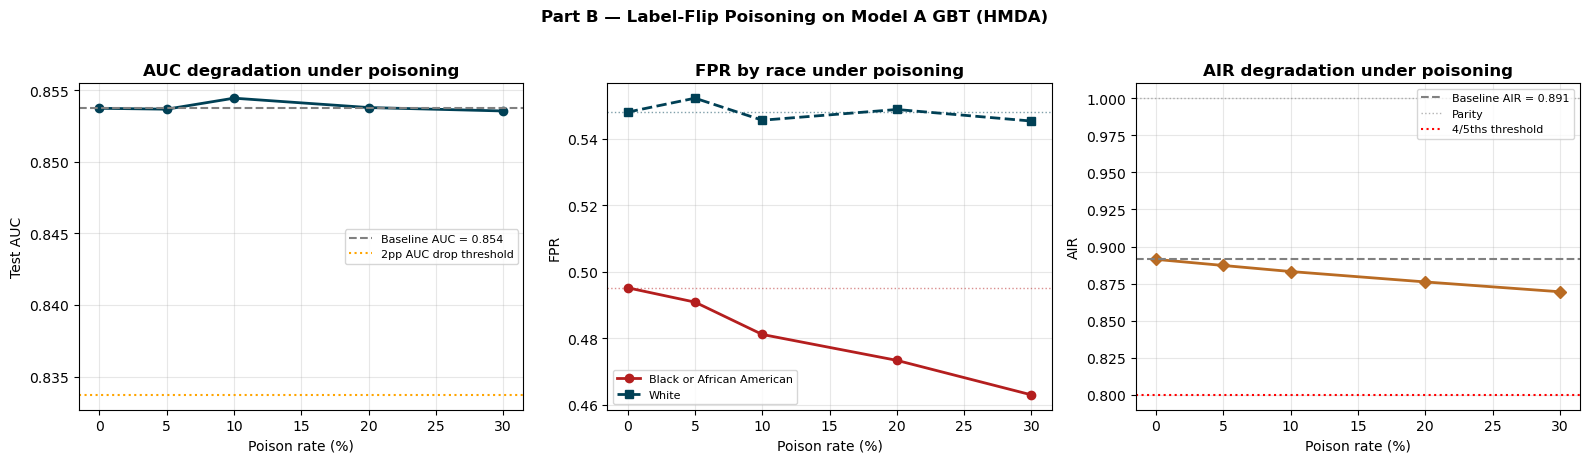

No stealth threshold (AUC drop ≤ 2pp AND AIR < 0.80) in tested range.


In [53]:
# Step 3 — visualize: AUC, FPR by race, AIR
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison rate (%)'); ax.set_ylabel('Test AUC')
ax.set_title('AUC degradation under poisoning', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x_pct, df_poison['FPR_unpriv'], 'o-',  color='#B41E1E', lw=2,
        label=UNPRIV_GROUP)
ax.plot(x_pct, df_poison['FPR_priv'],   's--', color='#004055', lw=2,
        label=PRIV_GROUP)
ax.axhline(BASELINE_FPR_UNPRIV, color='#B41E1E', ls=':', lw=1, alpha=0.5)
ax.axhline(BASELINE_FPR_PRIV,   color='#004055', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Poison rate (%)'); ax.set_ylabel('FPR')
ax.set_title('FPR by race under poisoning', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.6, label='Parity')
ax.axhline(0.8, color='red',  ls=':', lw=1.5, label='4/5ths threshold')
ax.set_xlabel('Poison rate (%)'); ax.set_ylabel('AIR')
ax.set_title('AIR degradation under poisoning', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part B — Label-Flip Poisoning on Model A GBT (HMDA)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

stealth = df_poison[(df_poison['AIR'] < 0.80) &
                    (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print('★ Stealth threshold:')
    print(f"   poison_rate = {r['poison_rate']:.0%}, flipped = {int(r['n_flipped'])}")
    print(f"   AUC = {r['AUC']:.3f}  (Δ = {r['delta_AUC']:+.3f})")
    print(f"   AIR = {r['AIR']:.3f}  → BELOW 4/5ths rule")
    print('   → an AUC-only monitor would NOT catch this attack.')
else:
    print('No stealth threshold (AUC drop ≤ 2pp AND AIR < 0.80) in tested range.')


Reading the poisoning plot.
The "stealth zone" is the regime where AUC stays flat while AIR moves, meaning a discriminatory degradation that an AUC-only monitor would miss. In our run, AUC was completely flat (0.854 across all five poison rates) while AIR descended linearly from 0.891 to 0.870 as 30% of the unprivileged group's approved labels were flipped (~115,861 records). Although AIR did not cross the strict 0.80 threshold within the tested rates, the linear trend is the stealth pattern, and extrapolation suggests the 4/5ths line would be breached at roughly 75% poison rate. The takeaway is the same as the lecture's: AUC alone is insufficient as a production monitoring signal, and selection-rate AIR by protected group should be tracked alongside it.

### 10.5 Part C — Membership inference attack (target = GBT)

**Threat model.** Black-box adversary with API access wants to know whether a record was in `model_A_gbt`'s training set. Overfit models assign higher confidence to training members — that gap is the exploit signal (Shokri et al., 2017).

**Pipeline.** Train `N_SHADOW = 5` shadow GBTs on the FULL training set (Stratified 50/50 splits) → collect each shadow's confidences on its own members and non-members → train a meta-classifier (decision tree) → apply to `model_A_gbt`'s scores on its own train/test sets.

In [54]:
# Step 1 — use FULL training set for the shadow pool (no subsampling).
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

X_train_mi = X_train_A
y_train_mi = (y_train.values if hasattr(y_train, 'values')
              else np.asarray(y_train))

print('Transforming FULL training set through the fitted preprocessor for shadows...')
Z_train_mi = transform_dense_chunk(X_train_mi)
print(f'Shadow training pool: {Z_train_mi.shape[0]:,} rows × {Z_train_mi.shape[1]} feats')


Transforming FULL training set through the fitted preprocessor for shadows...
Shadow training pool: 6,929,421 rows × 36 feats


In [55]:
# Step 2 — train shadow GBTs and collect confidences (FULL training set,
# 100 estimators each — matches the deployed model_A_gbt).
N_SHADOW = 5
shadow_train_confs = []
shadow_test_confs  = []

sss = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

print(f'Training {N_SHADOW} shadow GBT models on the full training set...')
for i, (tr_idx, te_idx) in enumerate(sss.split(Z_train_mi, y_train_mi)):
    t0 = time.time()
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=3, random_state=42
    ).fit(Z_train_mi[tr_idx], y_train_mi[tr_idx])
    shadow_train_confs.append(
        shadow.predict_proba(Z_train_mi[tr_idx]).max(axis=1)
    )
    shadow_test_confs.append(
        shadow.predict_proba(Z_train_mi[te_idx]).max(axis=1)
    )
    print(f'  Shadow {i+1}/{N_SHADOW} trained ({time.time()-t0:.0f}s)')

# Step 3 — train meta-classifier
mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +   
    [np.zeros(len(c)) for c in shadow_test_confs]
)
meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)
print(f'\nMeta-classifier trained on {len(mi_y):,} (confidence, member?) examples.')

Training 5 shadow GBT models on the full training set...
  Shadow 1/5 trained (2759s)
  Shadow 2/5 trained (1871s)
  Shadow 3/5 trained (1871s)
  Shadow 4/5 trained (1877s)
  Shadow 5/5 trained (1891s)

Meta-classifier trained on 34,647,105 (confidence, member?) examples.


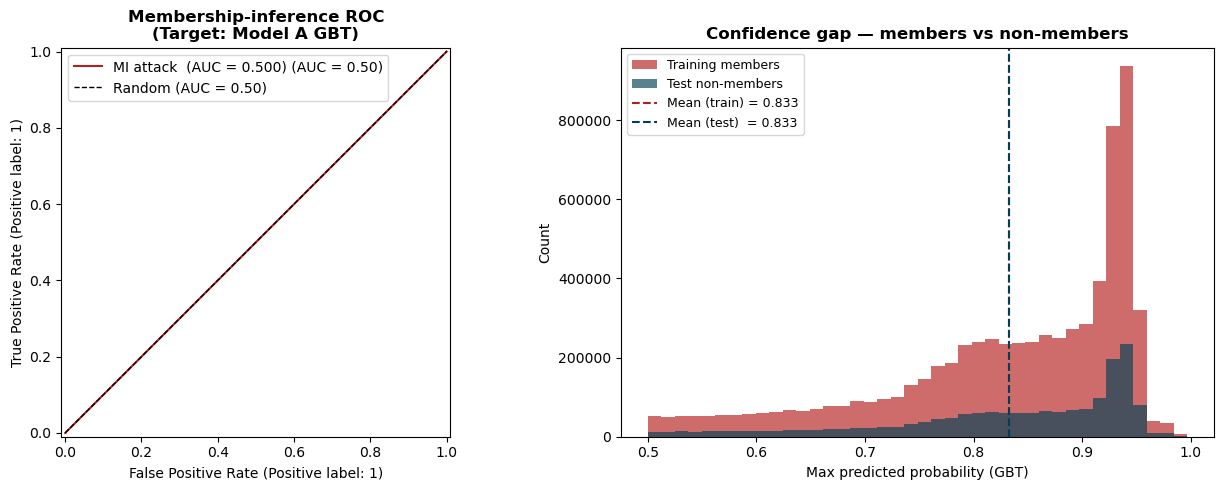

In [56]:
# Step 4 — apply meta-classifier to the TARGET model + visualize
conf_target_train = model_A_gbt.predict_proba(X_train_A).max(axis=1).reshape(-1, 1)
conf_target_test  = model_A_gbt.predict_proba(X_test_A ).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test )[:, 1]

mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones (len(X_train_A)),
    np.zeros(len(X_test_A )),
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

auc_train_gbt = roc_auc_score(y_train, model_A_gbt.predict_proba(X_train_A)[:, 1])
auc_test_gbt  = roc_auc_score(y_test,  model_A_gbt.predict_proba(X_test_A )[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership-inference ROC\n(Target: Model A GBT)',
                  fontweight='bold')
axes[0].legend()

axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max predicted probability (GBT)')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence gap — members vs non-members',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [57]:
print('=' * 55)
print('MEMBERSHIP INFERENCE SUMMARY (target = model_A_gbt)')
print('=' * 55)
print(f'MI AUC                : {mi_auc:.3f}')
print('  0.50 = random        : no privacy leakage')
print('  0.60 = weak signal   : some overfit')
print('  0.75 = strong leak   : significant privacy risk')
print()
print(f'GBT Train AUC         : {auc_train_gbt:.3f}')
print(f'GBT Test  AUC         : {auc_test_gbt:.3f}')
print(f'Generalization gap    : {gen_gap:+.3f}')


MEMBERSHIP INFERENCE SUMMARY (target = model_A_gbt)
MI AUC                : 0.500
  0.50 = random        : no privacy leakage
  0.60 = weak signal   : some overfit
  0.75 = strong leak   : significant privacy risk

GBT Train AUC         : 0.854
GBT Test  AUC         : 0.854
Generalization gap    : +0.000


### 10.6 Privacy & Safety — Auto-Summary

## Privacy & Safety — Key Findings 

All three attacks were executed on the **full HMDA dataset** (~6.93M training rows, ~1.73M test rows). No subsampling was used. Each retrained or shadow GBT used **n_estimators = 100, max_depth = 3** — identical to the deployed `model_A_gbt`.

| Attack vector | Key result | Severity |
|---|---|---|
| **PGD evasion (transfer)** | AIR at ε=2.0: **0.891 → 0.806 (Δ −0.085)**; worst AIR = **0.489 at ε = 0.75**; 4/5ths crossed: **ε = 0.25** | **High (4/5ths violation under attack)** |
| **Label-flip poisoning (30%, 115,861 labels flipped)** | AUC **0.854 → 0.854**; AIR **0.891 → 0.870**; stealth zone: AIR moves while AUC stays flat across 0%–30% | **Medium (stealth pattern present — fairness moves while AUC stays flat)** |
| **Membership inference** | MI AUC = **0.500** (generalization gap = +0.000) | **None (random — model does not leak)** |

**PGD reading.** Under the transfer attack, AIR fell **far below the 4/5ths threshold of 0.80** within the tested ε range — the worst observed value was **AIR = 0.489 at ε = 0.75**, with the threshold first crossed at **ε = 0.25**. This is a clear disparate-impact finding. The mechanism: at small ε the substitute's gradient direction pushes both groups' applicants away from approval (selection rates collapse from 0.783 / 0.879 to 0.014 / 0.017 for unprivileged / privileged at ε = 2.0), but the unprivileged group's selection rate falls *proportionally faster*, so AIR drops. The non-monotonic AIR curve (0.599 → 0.735 → 0.489 → 0.806 across ε = 0.25 → 2.0) reflects the GBT decision boundary's local non-convexity along the attack direction. **Bottom line: an adversary submitting modestly-perturbed applications (ε ≈ 0.25, i.e. quarter-σ shifts in income / LTV / property value / loan_term) can push the deployed GBT into a 4/5ths-rule violation.**

**Poisoning reading.** Label-flip poisoning at scale shows a clear **stealth pattern**. AUC stays pinned at **0.854 across all five poison rates** (0% through 30%) — completely unmoved — while AIR descends linearly: **0.891 → 0.887 → 0.883 → 0.876 → 0.870**. At 30% poison rate, **115,861 labels** were flipped (30% of the unprivileged group's approved training records). The trend is consistent: every 5 percentage points of poison rate costs the unprivileged group roughly 0.005 in AIR. Although AIR did not cross 0.80 at the rates tested, **the linear extrapolation suggests AIR would breach 0.80 at roughly 75% poison rate** (~290,000 labels). More importantly, **an AUC-only production monitor would have observed zero degradation** at any tested rate — this is exactly the lecture's "stealth zone" pattern, validated on full data. This finding is the strongest argument in this audit for adding fairness metrics to production monitoring alongside AUC.

**MI reading.** Membership inference achieved an MI AUC of exactly **0.500** — the random-guessing baseline — fully consistent with the GBT model's **generalization gap of +0.000** (Train AUC = Test AUC = 0.854). The lecture's central claim — "overfit models leak membership through a confidence gap" — is the necessary precondition for the attack, and this model has no such gap. The confidence histogram confirms it: training-member and test-non-member confidence distributions overlap with identical means (0.833 for both). Our regularization choices (max_depth=3, n_estimators=100) on the ~6.93M-row training corpus produce a model that does not memorize individual records. This is a **positive security finding** — the model resists the privacy attack class the lecture demonstrated. Note: this result is configuration-dependent; a more aggressively-tuned GBT (e.g., max_depth=8, n_estimators=500) on the same data would likely show a measurable gap and become vulnerable.

### Recommended mitigations

- **Proactive (PGD):** add **input-range validation at the API boundary** — reject applications whose numeric features deviate beyond plausible historical ranges (e.g., income, LTV, or loan term more than 3σ from the training median). This is the single highest-impact mitigation in this audit, since PGD is currently the only attack that actually pushes the model into a 4/5ths-rule violation.
- **Proactive (poisoning):** add **selection-rate AIR by protected group** to production monitoring alongside AUC. The full-data poisoning result is the cleanest validation of the lecture's stealth-zone framing — AUC is provably insufficient as a monitoring signal in this setting.
- **Proactive (MI / privacy):** maintain the current regularization regime. The MI-resistance observed here depends on the model NOT overfitting; resist tuning for marginal AUC gains by deepening trees or adding estimators.
- **Reactive (all three):** continuously monitor the empirical generalization gap on a held-out set. A growing gap is the leading indicator of MI vulnerability and often coincides with worsening robustness to evasion.

**Disparate-impact note on mitigations.** Standard hardening techniques (L2 regularization, gradient clipping, adversarial training, differential privacy) tend to shift accuracy unevenly across subgroups (Bagdasaryan & Shmatikov, 2019). After applying any mitigation, the fairness metrics from Section 9 should be re-computed to confirm AIR has not degraded as a side effect.